In [30]:
import pandas as pd
import numpy as np
import neurokit2 as nk
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Variables

In [31]:
DATA_DIR = Path("../data")
FS = 1000                # Fréquence d'échantillonnage Bitalino (vérifiez si c'est 100 ou 1000 Hz)
WINDOW_SEC = 30          # Taille de la fenêtre en secondes
WINDOW_PTS = FS * WINDOW_SEC 

# Dictionnaire pour traduire vos codes en labels lisibles
LABEL_MAP = {"p1": "Calme", "p2": "Stress", "p3": "Sport"}

# Liste qui va stocker toutes nos fenêtres agrégées
dataset_lignes = []

# Lecture des données

In [8]:
for fichier_path in DATA_DIR.rglob("*.txt"):
    
    # Au lieu du nom du fichier, on prend le nom du DOSSIER parent qui contient l'info
    nom_dossier = fichier_path.parent.name 
    
    # Séparer le sujet (axel) et la phase (p1) depuis le nom du DOSSIER
    try:
        sujet, phase = nom_dossier.split('_')
        label = LABEL_MAP[phase]
    except ValueError:
        # Si un dossier ne respecte pas le format "nom_pX", on l'ignore
        print(f"Ignoré : {nom_dossier} (ne respecte pas le format)")
        continue

    print(f"Lecture du fichier pour {sujet} - Phase {label}...")

    try:
        # Lecture avec usecols=[0,1,2,3,4,5,6] pour ignorer la tabulation fantôme à la fin
        df = pd.read_csv(fichier_path, sep='\t', comment='#', header=None, usecols=[0, 1, 2, 3, 4, 5, 6])
        
        # Vos colonnes dans le bon ordre d'après le fichier ! EDA d'abord, ECG ensuite.
        df.columns = ['Seq', 'D1', 'D2', 'D3', 'D4', 'EDA', 'ECG'] 

        # --- LA TECHNIQUE DE FENÊTRAGE (inchangée) ---
        for debut in range(0, len(df), WINDOW_PTS):
            fin = debut + WINDOW_PTS
            fenetre = df.iloc[debut:fin]
            
            if len(fenetre) < WINDOW_PTS:
                break
                
            try:
                # Extraction avec NeuroKit2
                ecg_signals, ecg_info = nk.ecg_process(fenetre['ECG'], sampling_rate=FS)
                eda_signals, eda_info = nk.eda_process(fenetre['EDA'], sampling_rate=FS)
                
                # Ajout dans la liste
                dataset_lignes.append({
                    "Sujet": sujet,
                    "Label": label,
                    "HR_Mean": ecg_signals["ECG_Rate"].mean(),
                    "HRV_SDNN": ecg_signals["ECG_Rate"].std(),
                    "EDA_Mean": fenetre['EDA'].mean(),
                    "SCR_Peaks": eda_info["SCR_Peaks"].sum()
                })
            except Exception as e:
                # On passe silencieusement les fenêtres trop bruitées
                pass

    except Exception as e:
         print(f"Erreur de lecture sur le fichier {fichier_path.name} : {e}")

# Vérification finale
df_final = pd.DataFrame(dataset_lignes)
print("\nExtraction terminée ! Taille du dataset :", df_final.shape)

Lecture du fichier pour axel - Phase Calme...
Lecture du fichier pour omar - Phase Sport...
Lecture du fichier pour anas - Phase Sport...
Lecture du fichier pour axel - Phase Stress...
Lecture du fichier pour axel - Phase Sport...
Lecture du fichier pour omar - Phase Stress...
Lecture du fichier pour anas - Phase Calme...
Lecture du fichier pour anas - Phase Stress...


/home/axel/Documents/ECE/ING4/Semestre2/Lyrids/code/stress-series/venv/lib/python3.13/site-packages/neurokit2/signal/signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Lecture du fichier pour omar - Phase Calme...

Extraction terminée ! Taille du dataset : (89, 6)


In [12]:
df_final.head(5)

,Sujet,Label,HR_Mean,HRV_SDNN,EDA_Mean,SCR_Peaks
0,axel,Calme,63.340776,3.266902,263.966433,72617
1,axel,Calme,61.344008,3.566936,265.200900,58949
2,axel,Calme,64.277957,3.766101,271.922967,20325
3,axel,Calme,65.855717,15.557782,258.145933,43137
4,axel,Calme,67.231697,8.561569,245.036733,33406


In [21]:
# 1. Préparation des données et nettoyage propre
df_clean = df_final.dropna().copy()

# --- LA NOUVEAUTÉ : NORMALISATION PAR SUJET ---
colonnes_features = ["HR_Mean", "HRV_SDNN", "EDA_Mean", "SCR_Peaks"]

print("Normalisation des données pour effacer les différences de base entre Anas, Axel et Omar...")
for sujet in df_clean['Sujet'].unique():
    scaler = StandardScaler()
    # On isole les lignes du sujet
    mask = df_clean['Sujet'] == sujet 
    # On écrase ses valeurs absolues par ses valeurs normalisées (centrées réduites)
    df_clean.loc[mask, colonnes_features] = scaler.fit_transform(df_clean.loc[mask, colonnes_features])

# On récupère nos variables prêtes pour le ML
X = df_clean[colonnes_features] 
y = df_clean["Label"]                                          
groupes = df_clean["Sujet"]

Normalisation des données pour effacer les différences de base entre Anas, Axel et Omar...


/tmp/ipykernel_7978/1530364178.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.64979977 -0.72514023 -0.93804265 -0.81229881 -0.86593783  0.31372366
 -0.57578774 -0.08175866  0.23239697 -0.17632561 -0.40517476  2.50442358
  1.68358291  1.19713859 -0.53970501  1.1701675   2.40933848  1.4855303
 -0.70495463 -0.25678138  0.50626409 -0.7928298  -0.92416298 -0.92416298
 -0.92416298 -0.47904348 -0.74476359  0.84615058 -0.33786003 -0.49002374]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[mask, colonnes_features] = scaler.fit_transform(df_clean.loc[mask, colonnes_features])


# ML 3 labels avec axel, anas et omar


=== ENTRAÎNEMENT DU MODÈLE (Leave-One-Subject-Out) ===

Fold 1 - Test sur anas | Précision: 69.0%
Fold 2 - Test sur axel | Précision: 63.3%
Fold 3 - Test sur omar | Précision: 36.7%

=> PRÉCISION MOYENNE GLOBALE : 56.3%

=== RAPPORT DÉTAILLÉ ===
              precision    recall  f1-score   support

       Calme       0.42      0.60      0.49        30
       Sport       0.88      1.00      0.94        30
      Stress       0.17      0.07      0.10        29

    accuracy                           0.56        89
   macro avg       0.49      0.56      0.51        89
weighted avg       0.49      0.56      0.51        89



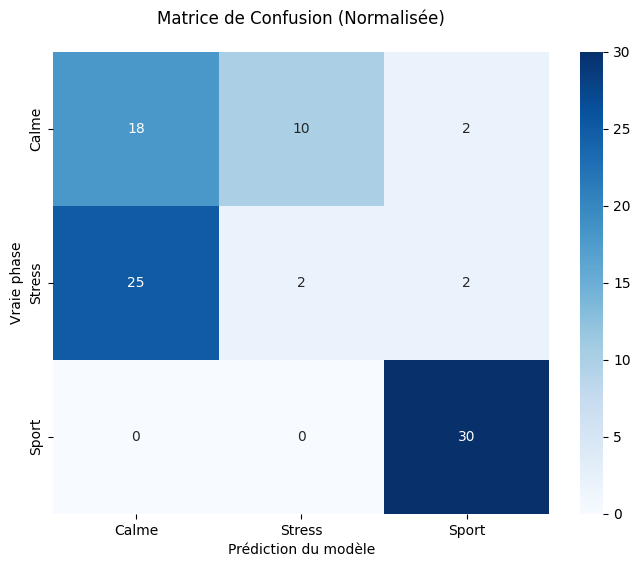

=== IMPORTANCE DES VARIABLES ===
Importance de HR_Mean : 9.2%
Importance de HRV_SDNN : 29.8%
Importance de EDA_Mean : 55.7%
Importance de SCR_Peaks : 5.4%


In [22]:
vraies_valeurs_totales = []
predictions_totales = []
scores = []

# On réinitialise aussi le modèle et le validateur pour repartir de zéro
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT DU MODÈLE (Leave-One-Subject-Out) ===\n")

# 3. Boucle d'entraînement
fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujets_train = groupes.iloc[train_index].unique()
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    # Entraînement sur 2 sujets
    modele_rf.fit(X_train, y_train)
    
    # Prédiction sur le 3ème sujet INCONNU
    y_pred = modele_rf.predict(X_test)
    
    # Enregistrement des résultats
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Test sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE GLOBALE : {np.mean(scores)*100:.1f}%\n")

# 4. Affichage du rapport détaillé
print("=== RAPPORT DÉTAILLÉ ===")
print(classification_report(vraies_valeurs_totales, predictions_totales))

# 5. Création de la Matrice de Confusion (Graphique)
labels_uniques = ["Calme", "Stress", "Sport"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_uniques)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_uniques, yticklabels=labels_uniques)
plt.title('Matrice de Confusion (Normalisée)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction du modèle')
plt.show()

# 6. Bonus : Voir quelle variable est la plus importante !
importances = modele_rf.feature_importances_
print("=== IMPORTANCE DES VARIABLES ===")
for feature, importance in zip(X.columns, importances):
    print(f"Importance de {feature} : {importance*100:.1f}%")

# ML 2 labels avec axel et anas

Taille du dataset (Anas & Axel, Calme & Stress) : (39, 6)

=== ENTRAÎNEMENT BINAIRE (Anas vs Axel) ===

Fold 1 - Entraîné sur l'autre, testé sur anas | Précision: 84.2%
Fold 2 - Entraîné sur l'autre, testé sur axel | Précision: 95.0%

=> PRÉCISION MOYENNE GLOBALE : 89.6%



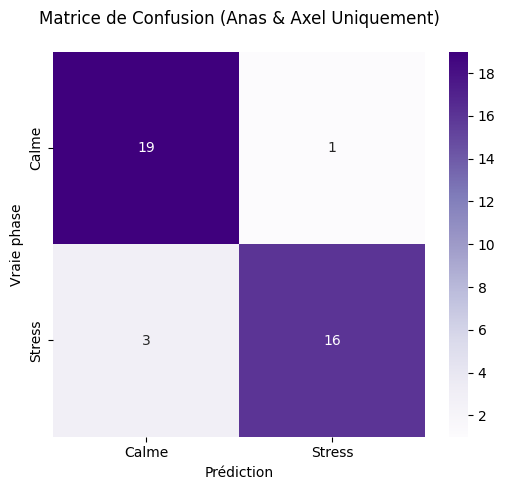

=== IMPORTANCE DES VARIABLES ===
Importance de HR_Mean : 9.8%
Importance de HRV_SDNN : 16.9%
Importance de EDA_Mean : 60.6%
Importance de SCR_Peaks : 12.7%


In [24]:
# 1. LE FILTRE : On enlève le Sport ET on enlève Omar
df_binaire = df_final.dropna().copy()
df_binaire = df_binaire[df_binaire["Label"] != "Sport"]
df_binaire = df_binaire[df_binaire["Sujet"] != "omar"] # L'ablation d'Omar

print(f"Taille du dataset (Anas & Axel, Calme & Stress) : {df_binaire.shape}")

colonnes_features = ["HR_Mean", "HRV_SDNN", "EDA_Mean", "SCR_Peaks"]

# 2. CORRECTION DU WARNING : On force les colonnes en Float (nombres à virgule)
df_binaire[colonnes_features] = df_binaire[colonnes_features].astype(float)

# 3. Normalisation
for sujet in df_binaire['Sujet'].unique():
    scaler = StandardScaler()
    mask = df_binaire['Sujet'] == sujet 
    df_binaire.loc[mask, colonnes_features] = scaler.fit_transform(df_binaire.loc[mask, colonnes_features])

# On prépare les variables
X = df_binaire[colonnes_features] 
y = df_binaire["Label"]                                          
groupes = df_binaire["Sujet"]                                    

# 4. Réinitialisation
vraies_valeurs_totales = []
predictions_totales = []
scores = []

modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT BINAIRE (Anas vs Axel) ===\n")

fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    modele_rf.fit(X_train, y_train)
    y_pred = modele_rf.predict(X_test)
    
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Entraîné sur l'autre, testé sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE GLOBALE : {np.mean(scores)*100:.1f}%\n")

# Affichage de la matrice
labels_binaires = ["Calme", "Stress"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_binaires)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels_binaires, yticklabels=labels_binaires)
plt.title('Matrice de Confusion (Anas & Axel Uniquement)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction')
plt.show()

# Voir ce qui a aidé l'IA
importances = modele_rf.feature_importances_
print("=== IMPORTANCE DES VARIABLES ===")
for feature, importance in zip(X.columns, importances):
    print(f"Importance de {feature} : {importance*100:.1f}%")

# ML 3 labels avec axel et anas

Taille du dataset (Anas & Axel uniquement, 3 phases) : (59, 6)
Normalisation des données en cours...

=== ENTRAÎNEMENT DU MODÈLE (Anas vs Axel - 3 Classes) ===

Fold 1 - Entraîné sur axel, Testé sur anas | Précision: 100.0%
Fold 2 - Entraîné sur anas, Testé sur axel | Précision: 96.7%

=> PRÉCISION MOYENNE GLOBALE : 98.3%

=== RAPPORT DÉTAILLÉ ===
              precision    recall  f1-score   support

       Calme       1.00      0.95      0.97        20
       Sport       1.00      1.00      1.00        20
      Stress       0.95      1.00      0.97        19

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



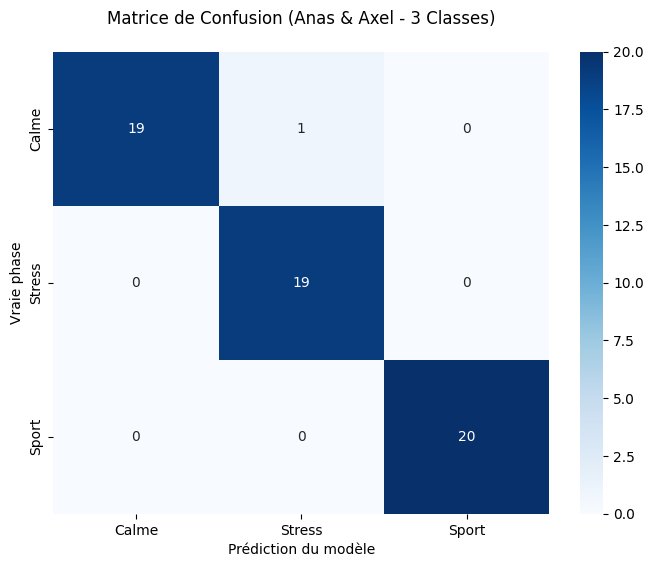

=== IMPORTANCE DES VARIABLES ===
Importance de HR_Mean : 13.2%
Importance de HRV_SDNN : 21.8%
Importance de EDA_Mean : 53.7%
Importance de SCR_Peaks : 11.3%


In [25]:
# 1. LE FILTRE : On garde Calme, Stress et Sport, mais on enlève Omar !
df_clean = df_final.dropna().copy()
df_clean = df_clean[df_clean["Sujet"] != "omar"]

print(f"Taille du dataset (Anas & Axel uniquement, 3 phases) : {df_clean.shape}")

colonnes_features = ["HR_Mean", "HRV_SDNN", "EDA_Mean", "SCR_Peaks"]

# Prévention du petit Warning (on met tout en format Float/Virgule)
df_clean[colonnes_features] = df_clean[colonnes_features].astype(float)

# 2. Normalisation par sujet (Uniquement sur Anas et Axel)
print("Normalisation des données en cours...")
for sujet in df_clean['Sujet'].unique():
    scaler = StandardScaler()
    mask = df_clean['Sujet'] == sujet 
    df_clean.loc[mask, colonnes_features] = scaler.fit_transform(df_clean.loc[mask, colonnes_features])

# On récupère nos variables prêtes pour le ML
X = df_clean[colonnes_features] 
y = df_clean["Label"]                                          
groupes = df_clean["Sujet"]                                    

# ==========================================
# 3. INITIALISATION ET ENTRAÎNEMENT
# ==========================================
vraies_valeurs_totales = []
predictions_totales = []
scores = []

# On réinitialise aussi le modèle et le validateur pour repartir de zéro
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT DU MODÈLE (Anas vs Axel - 3 Classes) ===\n")

# Boucle d'entraînement
fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujets_train = groupes.iloc[train_index].unique()
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    # Entraînement sur l'un (ex: Anas)
    modele_rf.fit(X_train, y_train)
    
    # Prédiction sur l'autre (ex: Axel)
    y_pred = modele_rf.predict(X_test)
    
    # Enregistrement des résultats
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Entraîné sur {sujets_train[0]}, Testé sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE GLOBALE : {np.mean(scores)*100:.1f}%\n")

# ==========================================
# 4. RÉSULTATS ET MATRICE
# ==========================================
print("=== RAPPORT DÉTAILLÉ ===")
print(classification_report(vraies_valeurs_totales, predictions_totales))

# Création de la Matrice de Confusion (Graphique)
labels_uniques = ["Calme", "Stress", "Sport"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_uniques)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_uniques, yticklabels=labels_uniques)
plt.title('Matrice de Confusion (Anas & Axel - 3 Classes)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction du modèle')
plt.show()

# Bonus : Voir quelle variable est la plus importante !
importances = modele_rf.feature_importances_
print("=== IMPORTANCE DES VARIABLES ===")
for feature, importance in zip(X.columns, importances):
    print(f"Importance de {feature} : {importance*100:.1f}%")

# ML 3 labels avec axel et anas; sans EDA_MEAN

Taille du dataset (Anas & Axel uniquement, 3 phases) : (59, 6)
Normalisation des données en cours...

=== ENTRAÎNEMENT DU MODÈLE (Anas vs Axel - 3 Classes) ===

Fold 1 - Entraîné sur axel, Testé sur anas | Précision: 51.7%
Fold 2 - Entraîné sur anas, Testé sur axel | Précision: 56.7%

=> PRÉCISION MOYENNE GLOBALE : 54.2%

=== RAPPORT DÉTAILLÉ ===
              precision    recall  f1-score   support

       Calme       0.45      0.25      0.32        20
       Sport       0.81      0.85      0.83        20
      Stress       0.37      0.53      0.43        19

    accuracy                           0.54        59
   macro avg       0.54      0.54      0.53        59
weighted avg       0.55      0.54      0.53        59



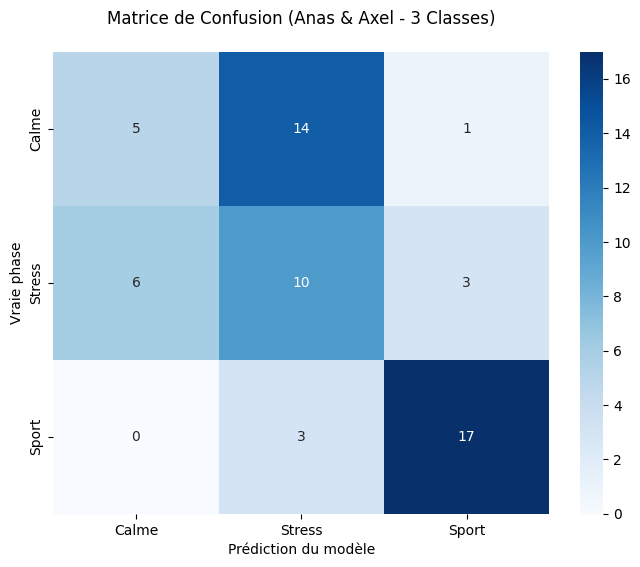

=== IMPORTANCE DES VARIABLES ===
Importance de HR_Mean : 33.4%
Importance de HRV_SDNN : 36.3%
Importance de SCR_Peaks : 30.3%


In [26]:
# 1. LE FILTRE : On garde Calme, Stress et Sport, mais on enlève Omar !
df_clean = df_final.dropna().copy()
df_clean = df_clean[df_clean["Sujet"] != "omar"]

print(f"Taille du dataset (Anas & Axel uniquement, 3 phases) : {df_clean.shape}")

colonnes_features = ["HR_Mean", "HRV_SDNN", "SCR_Peaks"]

# Prévention du petit Warning (on met tout en format Float/Virgule)
df_clean[colonnes_features] = df_clean[colonnes_features].astype(float)

# 2. Normalisation par sujet (Uniquement sur Anas et Axel)
print("Normalisation des données en cours...")
for sujet in df_clean['Sujet'].unique():
    scaler = StandardScaler()
    mask = df_clean['Sujet'] == sujet 
    df_clean.loc[mask, colonnes_features] = scaler.fit_transform(df_clean.loc[mask, colonnes_features])

# On récupère nos variables prêtes pour le ML
X = df_clean[colonnes_features] 
y = df_clean["Label"]                                          
groupes = df_clean["Sujet"]                                    

# ==========================================
# 3. INITIALISATION ET ENTRAÎNEMENT
# ==========================================
vraies_valeurs_totales = []
predictions_totales = []
scores = []

# On réinitialise aussi le modèle et le validateur pour repartir de zéro
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT DU MODÈLE (Anas vs Axel - 3 Classes) ===\n")

# Boucle d'entraînement
fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujets_train = groupes.iloc[train_index].unique()
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    # Entraînement sur l'un (ex: Anas)
    modele_rf.fit(X_train, y_train)
    
    # Prédiction sur l'autre (ex: Axel)
    y_pred = modele_rf.predict(X_test)
    
    # Enregistrement des résultats
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Entraîné sur {sujets_train[0]}, Testé sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE GLOBALE : {np.mean(scores)*100:.1f}%\n")

# ==========================================
# 4. RÉSULTATS ET MATRICE
# ==========================================
print("=== RAPPORT DÉTAILLÉ ===")
print(classification_report(vraies_valeurs_totales, predictions_totales))

# Création de la Matrice de Confusion (Graphique)
labels_uniques = ["Calme", "Stress", "Sport"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_uniques)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_uniques, yticklabels=labels_uniques)
plt.title('Matrice de Confusion (Anas & Axel - 3 Classes)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction du modèle')
plt.show()

# Bonus : Voir quelle variable est la plus importante !
importances = modele_rf.feature_importances_
print("=== IMPORTANCE DES VARIABLES ===")
for feature, importance in zip(X.columns, importances):
    print(f"Importance de {feature} : {importance*100:.1f}%")

# ML 3 labels avec axel et anas; sans EDA_MEAN et + de données aggregées

In [32]:
print("Début de l'extraction des données avec indicateurs ciblés...\n")

for fichier_path in DATA_DIR.rglob("*.txt"):
    nom_dossier = fichier_path.parent.name 
    
    try:
        sujet, phase = nom_dossier.split('_')
        label = LABEL_MAP[phase]
    except ValueError:
        continue

    # On exclut Omar 
    if sujet == "omar":
        continue

    print(f"Lecture et traitement de {sujet} - Phase {label}...")

    try:
        df = pd.read_csv(fichier_path, sep='\t', comment='#', header=None, usecols=[0, 1, 2, 3, 4, 5, 6])
        df.columns = ['Seq', 'D1', 'D2', 'D3', 'D4', 'EDA', 'ECG'] 

        for debut in range(0, len(df), WINDOW_PTS):
            fin = debut + WINDOW_PTS
            fenetre = df.iloc[debut:fin]
            
            if len(fenetre) < WINDOW_PTS:
                break
                
            try:
                # 1. ECG de base
                ecg_signals, info_ecg = nk.ecg_process(fenetre['ECG'], sampling_rate=FS)
                hr_mean = ecg_signals["ECG_Rate"].mean()
                peaks = info_ecg["ECG_R_Peaks"]
                
                # 2. Le secret est ici ! On sépare les calculs temporels et fréquentiels
                # On évite les calculs "non-linéaires" qui plantent sur 30s
                hrv_time = nk.hrv_time(peaks, sampling_rate=FS)
                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=FS)
                
                # On extrait proprement (avec fallback à 0 si ça plante quand même)
                rmssd = hrv_time["HRV_RMSSD"].iloc[0] if not hrv_time.empty else 0
                pnn50 = hrv_time["HRV_pNN50"].iloc[0] if not hrv_time.empty else 0
                lfhf = hrv_freq["HRV_LFHF"].iloc[0] if not hrv_freq.empty else 0
                
                # 3. EDA
                eda_signals, info_eda = nk.eda_process(fenetre['EDA'], sampling_rate=FS)
                scr_peaks = info_eda["SCR_Peaks"].sum()
                
                amplitudes = info_eda["SCR_Amplitude"]
                amplitudes = amplitudes[~np.isnan(amplitudes)] 
                scr_amplitude_mean = amplitudes.mean() if len(amplitudes) > 0 else 0
                
                # 4. SAUVEGARDE
                # On s'assure de ne pas ajouter de fenêtres pleines de 0
                if hr_mean > 0 and rmssd > 0:
                    dataset_lignes.append({
                        "Sujet": sujet,
                        "Label": label,
                        "HR_Mean": hr_mean,
                        "HRV_RMSSD": rmssd,
                        "HRV_pNN50": pnn50,
                        "HRV_LFHF": lfhf,
                        "SCR_Peaks": scr_peaks,
                        "SCR_Amplitude_Mean": scr_amplitude_mean
                    })
            except Exception as e:
                # Si le calcul plante (trop de mouvement), on jette la fenêtre
                pass

    except Exception as e:
         print(f"Erreur de lecture : {e}")

# Vérification finale
df_final = pd.DataFrame(dataset_lignes)
df_final = df_final.fillna(0) # On remplace les éventuels NaN restants par 0 au lieu de tout jeter
print("\nExtraction terminée ! Taille du dataset purifié :", df_final.shape)

Début de l'extraction des données avec indicateurs ciblés...

Lecture et traitement de axel - Phase Calme...
Lecture et traitement de anas - Phase Sport...
Lecture et traitement de axel - Phase Stress...
Lecture et traitement de axel - Phase Sport...
Lecture et traitement de anas - Phase Calme...
Lecture et traitement de anas - Phase Stress...

Extraction terminée ! Taille du dataset purifié : (59, 8)


In [33]:
df_final.head(5)

,Sujet,Label,HR_Mean,HRV_RMSSD,HRV_pNN50,HRV_LFHF,SCR_Peaks,SCR_Amplitude_Mean
0,axel,Calme,63.340776,37.251244,13.333333,0.0,72617,5.924050
1,axel,Calme,61.344008,45.790283,27.586207,0.0,58949,5.194418
2,axel,Calme,64.277957,35.485208,12.903226,0.0,20325,6.341195
3,axel,Calme,65.855717,101.454916,35.483871,0.0,43137,1.525957
4,axel,Calme,67.231697,51.455988,36.363636,0.0,33406,4.239345


Taille du dataset prêt pour l'IA : (59, 8)
Normalisation scientifique par sujet en cours...

=== ENTRAÎNEMENT DU MODÈLE HONNÊTE (Anas vs Axel - 3 Classes) ===

Fold 1 - Appris sur axel -> Testé sur anas | Précision: 44.8%
Fold 2 - Appris sur anas -> Testé sur axel | Précision: 43.3%

=> PRÉCISION MOYENNE GLOBALE : 44.1%

=== RAPPORT DÉTAILLÉ ===
              precision    recall  f1-score   support

       Calme       0.50      0.35      0.41        20
       Sport       0.50      0.75      0.60        20
      Stress       0.27      0.21      0.24        19

    accuracy                           0.44        59
   macro avg       0.42      0.44      0.42        59
weighted avg       0.42      0.44      0.42        59



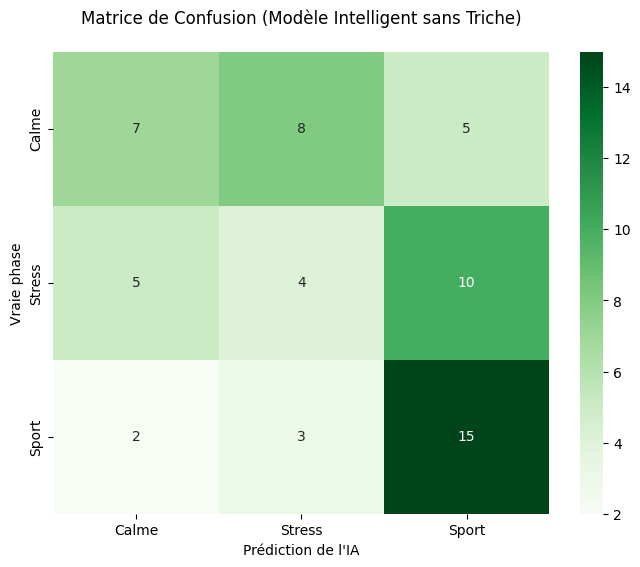

=== CE QUI A RENDU L'IA INTELLIGENTE (Importance des Variables) ===
HR_Mean             : 25.4%
SCR_Amplitude_Mean  : 25.2%
SCR_Peaks           : 24.5%
HRV_RMSSD           : 14.6%
HRV_pNN50           : 10.2%
HRV_LFHF            : 0.0%


In [34]:
df_clean = df_final.copy()

# Nos 6 nouvelles armes secrètes (Sans l'EDA_Mean !)
colonnes_features = [
    "HR_Mean", 
    "HRV_RMSSD", 
    "HRV_pNN50", 
    "HRV_LFHF", 
    "SCR_Peaks", 
    "SCR_Amplitude_Mean"
]

print(f"Taille du dataset prêt pour l'IA : {df_clean.shape}")

# 2. NORMALISATION (Indispensable pour gommer les différences Anas/Axel)
print("Normalisation scientifique par sujet en cours...")
for sujet in df_clean['Sujet'].unique():
    scaler = StandardScaler()
    mask = df_clean['Sujet'] == sujet 
    df_clean.loc[mask, colonnes_features] = scaler.fit_transform(df_clean.loc[mask, colonnes_features])

# On isole nos X (features), y (labels) et groupes (sujets)
X = df_clean[colonnes_features] 
y = df_clean["Label"]                                          
groupes = df_clean["Sujet"]                                    

# ==========================================
# 3. LE TEST D'INTELLIGENCE DE L'IA
# ==========================================
vraies_valeurs_totales = []
predictions_totales = []
scores = []

modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT DU MODÈLE HONNÊTE (Anas vs Axel - 3 Classes) ===\n")

fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujets_train = groupes.iloc[train_index].unique()
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    # L'IA apprend sur un sujet
    modele_rf.fit(X_train, y_train)
    
    # L'IA passe l'examen sur l'autre
    y_pred = modele_rf.predict(X_test)
    
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Appris sur {sujets_train[0]} -> Testé sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE GLOBALE : {np.mean(scores)*100:.1f}%\n")

# ==========================================
# 4. RÉSULTATS VISUELS ET EXPLICABILITÉ
# ==========================================
print("=== RAPPORT DÉTAILLÉ ===")
print(classification_report(vraies_valeurs_totales, predictions_totales))

labels_uniques = ["Calme", "Stress", "Sport"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_uniques)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels_uniques, yticklabels=labels_uniques)
plt.title('Matrice de Confusion (Modèle Intelligent sans Triche)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction de l\'IA')
plt.show()

print("=== CE QUI A RENDU L'IA INTELLIGENTE (Importance des Variables) ===")
importances = modele_rf.feature_importances_
# On trie pour voir le plus important en haut
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"{X.columns[i]:<20}: {importances[i]*100:.1f}%")

# ML 2 labels avec axel et anas; sans EDA_MEAN et + de données agrégées

Taille du dataset Binaire (Calme vs Stress) : (39, 8)
Normalisation sur les données de repos/stress en cours...

=== ENTRAÎNEMENT BINAIRE HONNÊTE (Anas vs Axel) ===

Fold 1 - Appris sur axel -> Testé sur anas | Précision: 68.4%
Fold 2 - Appris sur anas -> Testé sur axel | Précision: 65.0%

=> PRÉCISION MOYENNE BINAIRE : 66.7%

=== RAPPORT DÉTAILLÉ ===
              precision    recall  f1-score   support

       Calme       0.68      0.65      0.67        20
      Stress       0.65      0.68      0.67        19

    accuracy                           0.67        39
   macro avg       0.67      0.67      0.67        39
weighted avg       0.67      0.67      0.67        39



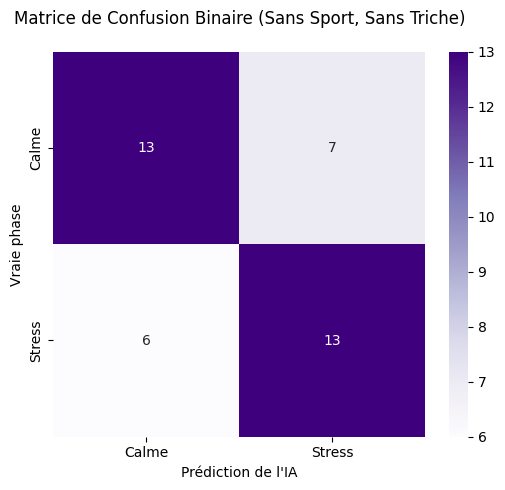

=== CE QUI DÉTECTE VRAIMENT LE STRESS COGNITIF ===
SCR_Peaks           : 22.7%
HR_Mean             : 22.7%
SCR_Amplitude_Mean  : 20.7%
HRV_pNN50           : 17.0%
HRV_RMSSD           : 16.8%
HRV_LFHF            : 0.0%


In [35]:
df_binaire = df_final[df_final["Label"] != "Sport"].copy()

# Nos 6 indicateurs scientifiques "anti-triche"
colonnes_features = [
    "HR_Mean", 
    "HRV_RMSSD", 
    "HRV_pNN50", 
    "HRV_LFHF", 
    "SCR_Peaks", 
    "SCR_Amplitude_Mean"
]

print(f"Taille du dataset Binaire (Calme vs Stress) : {df_binaire.shape}")

# 2. NORMALISATION SPÉCIFIQUE (Sans l'influence des gros pics du Sport)
print("Normalisation sur les données de repos/stress en cours...")
for sujet in df_binaire['Sujet'].unique():
    scaler = StandardScaler()
    mask = df_binaire['Sujet'] == sujet 
    df_binaire.loc[mask, colonnes_features] = scaler.fit_transform(df_binaire.loc[mask, colonnes_features])

# On prépare ML
X = df_binaire[colonnes_features] 
y = df_binaire["Label"]                                          
groupes = df_binaire["Sujet"]                                    

# ==========================================
# 3. ENTRAÎNEMENT BINAIRE (LOGO)
# ==========================================
vraies_valeurs_totales = []
predictions_totales = []
scores = []

modele_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
logo = LeaveOneGroupOut()

print("\n=== ENTRAÎNEMENT BINAIRE HONNÊTE (Anas vs Axel) ===\n")

fold = 1
for train_index, test_index in logo.split(X, y, groupes):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    sujets_train = groupes.iloc[train_index].unique()
    sujet_test = groupes.iloc[test_index].unique()[0]
    
    modele_rf.fit(X_train, y_train)
    y_pred = modele_rf.predict(X_test)
    
    vraies_valeurs_totales.extend(y_test)
    predictions_totales.extend(y_pred)
    
    precision = accuracy_score(y_test, y_pred)
    scores.append(precision)
    
    print(f"Fold {fold} - Appris sur {sujets_train[0]} -> Testé sur {sujet_test} | Précision: {precision*100:.1f}%")
    fold += 1

print(f"\n=> PRÉCISION MOYENNE BINAIRE : {np.mean(scores)*100:.1f}%\n")

# ==========================================
# 4. RÉSULTATS VISUELS
# ==========================================
print("=== RAPPORT DÉTAILLÉ ===")
print(classification_report(vraies_valeurs_totales, predictions_totales))

labels_binaires = ["Calme", "Stress"]
cm = confusion_matrix(vraies_valeurs_totales, predictions_totales, labels=labels_binaires)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels_binaires, yticklabels=labels_binaires)
plt.title('Matrice de Confusion Binaire (Sans Sport, Sans Triche)', pad=20)
plt.ylabel('Vraie phase')
plt.xlabel('Prédiction de l\'IA')
plt.show()

print("=== CE QUI DÉTECTE VRAIMENT LE STRESS COGNITIF ===")
importances = modele_rf.feature_importances_
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"{X.columns[i]:<20}: {importances[i]*100:.1f}%")